# 🚗 Car Price Prediction with Machine Learning

> Predict the **resale value of used cars** using regression models, interactive EDA, and a Streamlit web app.

---

**Steps:**

1. Import Libraries
2. Load & Explore Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Comparison (Linear Regression vs Ridge vs Random Forest vs Gradient Boosting)
6. Train Best Model (Gradient Boosting)
7. Evaluate & Visualize
8. SHAP Feature Importance
9. Save Model & Encoders


## 📦 Cell 1 — Import Libraries

In [24]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
os.makedirs("screenshots", exist_ok=True)
os.makedirs("encoders", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "#0d1b2a",
    "axes.facecolor":   "#0d1b2a",
    "axes.edgecolor":   "#2a3f5f",
    "axes.labelcolor":  "#c8dcff",
    "xtick.color":      "#8aafd4",
    "ytick.color":      "#8aafd4",
    "text.color":       "#c8dcff",
    "grid.color":       "#1e2f45",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "DejaVu Sans",
})
PALETTE = ["#00e896", "#0f9fcb", "#7c5cbf", "#f5a623", "#e05c5c"]
print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 📂 Cell 2 — Load & Explore Dataset

In [25]:
df = pd.read_csv("car_data.csv")
print(f"Dataset Shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
df.head(10)


Dataset Shape : (301, 9)
Columns       : ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [26]:
print("─── Data Types & Null Counts ───")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())


─── Data Types & Null Counts ───
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [27]:
print("─── Descriptive Statistics ───")
df.describe()


─── Descriptive Statistics ───


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [28]:
print("─── Categorical Value Counts ───\n")
for col in ["Fuel_Type", "Selling_type", "Transmission", "Owner"]:
    print(f"  {col}:")
    print(df[col].value_counts().to_string(), "\n")


─── Categorical Value Counts ───

  Fuel_Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2 

  Selling_type:
Selling_type
Dealer        195
Individual    106 

  Transmission:
Transmission
Manual       261
Automatic     40 

  Owner:
Owner
0    290
1     10
3      1 



## 📊 Cell 3 — Exploratory Data Analysis (EDA)

### 3.1 — Price Distributions

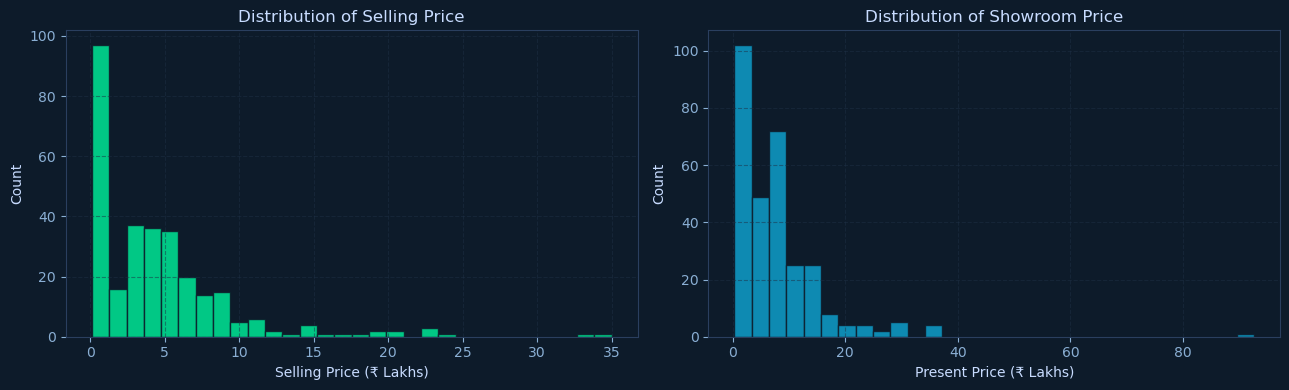

💾 Saved → screenshots/price_distributions.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["Selling_Price"], bins=30, color=PALETTE[0], edgecolor="#0d1b2a", alpha=0.85)
axes[0].set_xlabel("Selling Price (₹ Lakhs)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Selling Price")
axes[0].grid(True)

axes[1].hist(df["Present_Price"], bins=30, color=PALETTE[1], edgecolor="#0d1b2a", alpha=0.85)
axes[1].set_xlabel("Present Price (₹ Lakhs)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Showroom Price")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("screenshots/price_distributions.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/price_distributions.png")


### 3.2 — Selling Price vs Kilometers Driven

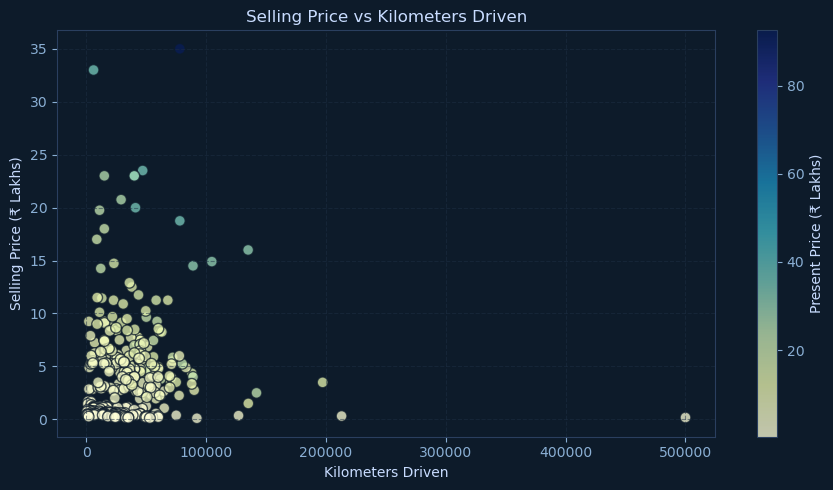

💾 Saved → screenshots/price_vs_kms.png


In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(df["Driven_kms"], df["Selling_Price"],
                c=df["Present_Price"], cmap="YlGnBu",
                alpha=0.75, s=60, edgecolors="#0d1b2a")
plt.colorbar(sc, ax=ax, label="Present Price (₹ Lakhs)")
ax.set_xlabel("Kilometers Driven")
ax.set_ylabel("Selling Price (₹ Lakhs)")
ax.set_title("Selling Price vs Kilometers Driven")
ax.grid(True)
plt.tight_layout()
plt.savefig("screenshots/price_vs_kms.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/price_vs_kms.png")


### 3.3 — Average Selling Price by Category

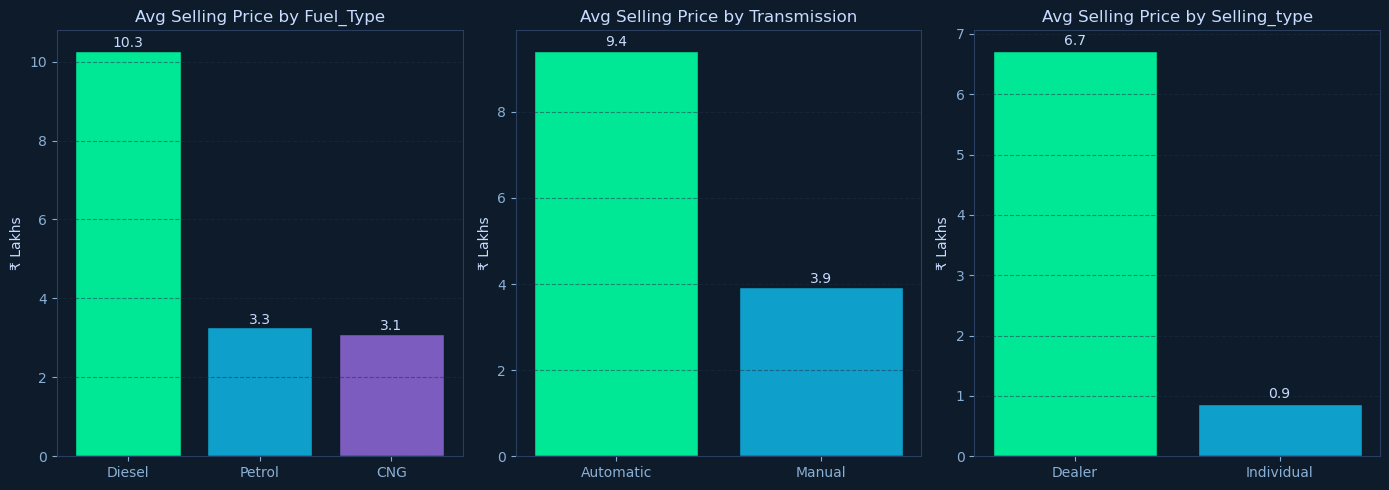

💾 Saved → screenshots/categorical_breakdown.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cats = ["Fuel_Type", "Transmission", "Selling_type"]
for ax, col in zip(axes, cats):
    means = df.groupby(col)["Selling_Price"].mean().sort_values(ascending=False)
    bars  = ax.bar(means.index, means.values,
                   color=PALETTE[:len(means)], edgecolor="#0d1b2a")
    ax.set_title(f"Avg Selling Price by {col}")
    ax.set_ylabel("₹ Lakhs")
    ax.grid(True, axis="y")
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.1f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("screenshots/categorical_breakdown.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/categorical_breakdown.png")


### 3.4 — Selling Price vs Showroom Price (by Fuel Type)

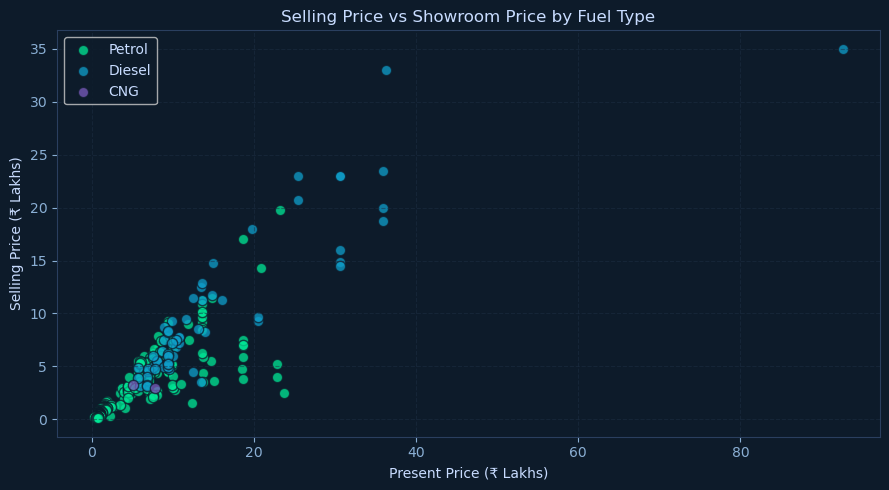

💾 Saved → screenshots/price_by_fuel.png


In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, fuel in enumerate(df["Fuel_Type"].unique()):
    subset = df[df["Fuel_Type"] == fuel]
    ax.scatter(subset["Present_Price"], subset["Selling_Price"],
               label=fuel, color=PALETTE[i], alpha=0.75, s=55, edgecolors="#0d1b2a")
ax.set_xlabel("Present Price (₹ Lakhs)")
ax.set_ylabel("Selling Price (₹ Lakhs)")
ax.set_title("Selling Price vs Showroom Price by Fuel Type")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("screenshots/price_by_fuel.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/price_by_fuel.png")


### 3.5 — Correlation Heatmap

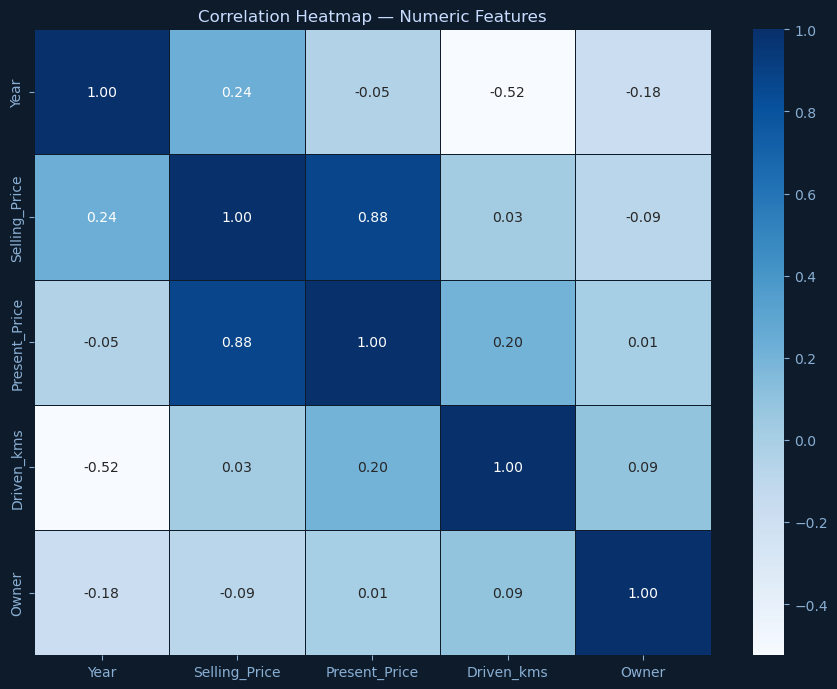

💾 Saved → screenshots/correlation_heatmap.png


In [33]:
num_df = df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, linecolor="#0d1b2a", ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("screenshots/correlation_heatmap.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/correlation_heatmap.png")


## ⚙️ Cell 4 — Data Preprocessing

Key steps:
- Create `Car_Age = 2024 − Year` to capture depreciation effect
- Drop `Car_Name` (too many unique values) and `Year` after extraction
- Label encode categorical columns
- **Save each encoder to `encoders/`** so `app.py` never uses hardcoded mappings

In [34]:
df["Car_Age"] = 2024 - df["Year"]
df.drop(columns=["Year", "Car_Name"], inplace=True)
print("✅ Car_Age created. Dropped: Year, Car_Name")
print(f"Car_Age range: {df['Car_Age'].min()} – {df['Car_Age'].max()} years")
df.head()


✅ Car_Age created. Dropped: Year, Car_Name
Car_Age range: 6 – 21 years


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [35]:
le_fuel         = LabelEncoder()
le_seller       = LabelEncoder()
le_transmission = LabelEncoder()

df["Fuel_Type"]    = le_fuel.fit_transform(df["Fuel_Type"])
df["Selling_type"] = le_seller.fit_transform(df["Selling_type"])
df["Transmission"] = le_transmission.fit_transform(df["Transmission"])

# Save encoders — app.py loads these instead of using hardcoded dicts
joblib.dump(le_fuel,         "encoders/le_fuel.pkl")
joblib.dump(le_seller,       "encoders/le_seller.pkl")
joblib.dump(le_transmission, "encoders/le_transmission.pkl")

print("✅ Label encoding done. Encoders saved to encoders/")
print(f"  Fuel classes        : {le_fuel.classes_}")
print(f"  Seller classes      : {le_seller.classes_}")
print(f"  Transmission classes: {le_transmission.classes_}")
df.head()


✅ Label encoding done. Encoders saved to encoders/
  Fuel classes        : ['CNG' 'Diesel' 'Petrol']
  Seller classes      : ['Dealer' 'Individual']
  Transmission classes: ['Automatic' 'Manual']


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,10
1,4.75,9.54,43000,1,0,1,0,11
2,7.25,9.85,6900,2,0,1,0,7
3,2.85,4.15,5200,2,0,1,0,13
4,4.60,6.87,42450,1,0,1,0,10


In [36]:
X = df.drop(columns=["Selling_Price"])
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Features  : {X.columns.tolist()}")
print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")


Features  : ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']
Train size: (240, 7)
Test size : (61, 7)


## 🔬 Cell 5 — Model Comparison (Linear Regression vs Ridge vs Random Forest vs Gradient Boosting)

All four models are evaluated on R², RMSE, MAE, and 5-fold cross-validated R².

In [37]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(
                             n_estimators=200, learning_rate=0.05,
                             max_depth=4, random_state=42),
}

results = []
trained = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    preds  = m.predict(X_test)
    r2     = r2_score(y_test, preds)
    rmse   = np.sqrt(mean_squared_error(y_test, preds))
    mae    = mean_absolute_error(y_test, preds)
    cv_r2  = cross_val_score(m, X, y, cv=5, scoring="r2").mean()
    results.append({"Model": name, "R²": round(r2,4), "RMSE": round(rmse,4),
                    "MAE": round(mae,4), "CV R²": round(cv_r2,4)})
    trained[name] = m
    print(f"{name:25s}  R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  CV_R²={cv_r2:.3f}")

results_df = pd.DataFrame(results)
results_df


Linear Regression          R²=0.847  RMSE=1.879  MAE=1.222  CV_R²=-18.285
Ridge Regression           R²=0.847  RMSE=1.875  MAE=1.218  CV_R²=-18.004
Random Forest              R²=0.959  RMSE=0.969  MAE=0.639  CV_R²=0.376
Gradient Boosting          R²=0.971  RMSE=0.812  MAE=0.529  CV_R²=0.510


,Model,R²,RMSE,MAE,CV R²
0,Linear Regression,0.8467,1.8792,1.2219,-18.2847
1,Ridge Regression,0.8473,1.8753,1.2183,-18.0038
2,Random Forest,0.9593,0.9686,0.6389,0.3757
3,Gradient Boosting,0.9714,0.8121,0.5288,0.5103


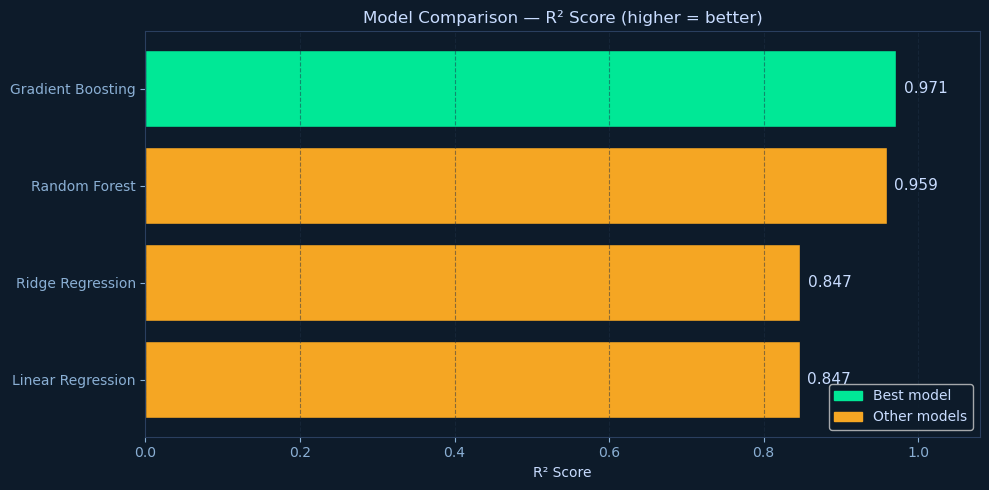

💾 Saved → screenshots/model_comparison.png


In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
best_r2 = results_df["R²"].max()
colors  = [PALETTE[0] if r == best_r2 else PALETTE[3] for r in results_df["R²"]]
bars    = ax.barh(results_df["Model"], results_df["R²"],
                  color=colors, edgecolor="#0d1b2a")
ax.set_xlabel("R² Score")
ax.set_title("Model Comparison — R² Score (higher = better)")
ax.set_xlim(0, 1.08)
for bar, val in zip(bars, results_df["R²"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=11, color="#c8dcff")
ax.grid(True, axis="x")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=PALETTE[0], label="Best model"),
    plt.Rectangle((0,0),1,1, color=PALETTE[3], label="Other models"),
], loc="lower right")
plt.tight_layout()
plt.savefig("screenshots/model_comparison.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/model_comparison.png")


## 🤖 Cell 6 — Train Best Model (Gradient Boosting)

In [39]:
best_model = trained["Gradient Boosting"]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
print("─── Gradient Boosting — Final Evaluation ───")
print(f"  R²   : {r2_score(y_test, y_pred):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} Lakhs")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred):.4f} Lakhs")


─── Gradient Boosting — Final Evaluation ───
  R²   : 0.9714
  RMSE : 0.8121 Lakhs
  MAE  : 0.5288 Lakhs


## 📈 Cell 7 — Evaluate & Visualize

### 7.1 — Prediction vs Actual

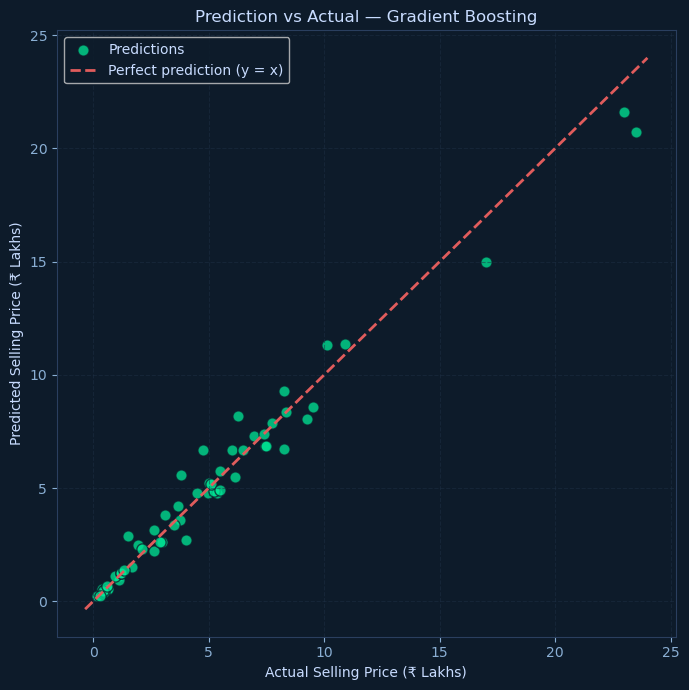

💾 Saved → screenshots/pred_vs_actual.png


In [40]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, color=PALETTE[0], alpha=0.75,
           edgecolors="#0d1b2a", s=65, label="Predictions")
lims = [min(y_test.min(), y_pred.min()) - 0.5,
        max(y_test.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, color=PALETTE[4], linewidth=2,
        linestyle="--", label="Perfect prediction (y = x)")
ax.set_xlabel("Actual Selling Price (₹ Lakhs)")
ax.set_ylabel("Predicted Selling Price (₹ Lakhs)")
ax.set_title("Prediction vs Actual — Gradient Boosting")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("screenshots/pred_vs_actual.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/pred_vs_actual.png")


### 7.2 — Residual Analysis

A well-fitted model has residuals that are **centered around 0** with **no visible pattern**.

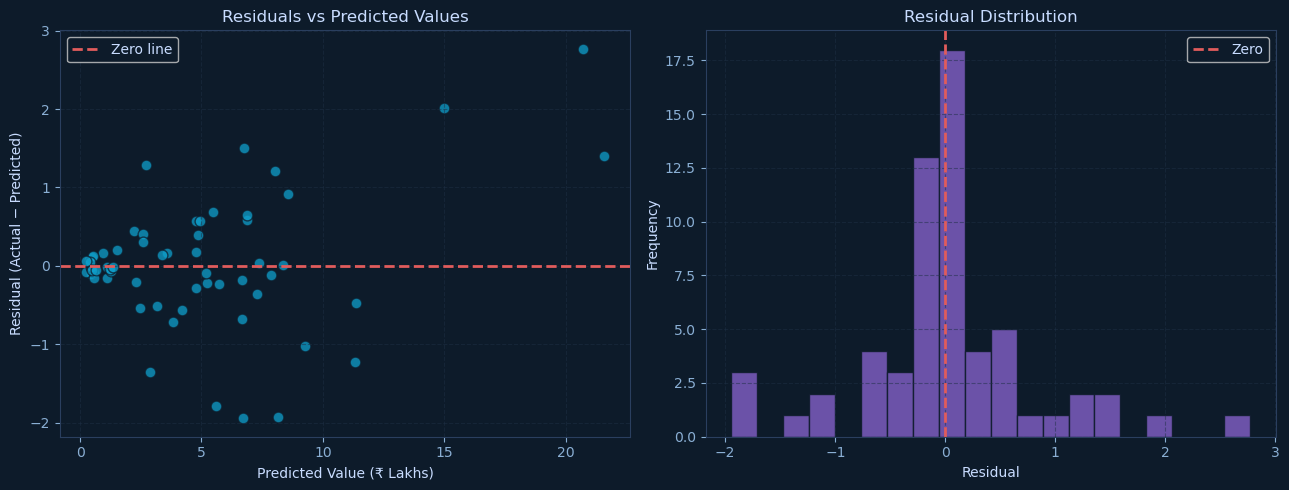

💾 Saved → screenshots/residual_plots.png

Mean Residual : 0.0287  (ideal ≈ 0)
Std  Residual : 0.8183


In [41]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, color=PALETTE[1], alpha=0.75,
                edgecolors="#0d1b2a", s=60)
axes[0].axhline(0, color=PALETTE[4], linewidth=2, linestyle="--", label="Zero line")
axes[0].set_xlabel("Predicted Value (₹ Lakhs)")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residuals vs Predicted Values")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(residuals, bins=20, color=PALETTE[2],
             edgecolor="#0d1b2a", alpha=0.85)
axes[1].axvline(0, color=PALETTE[4], linewidth=2, linestyle="--", label="Zero")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("screenshots/residual_plots.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()
print("💾 Saved → screenshots/residual_plots.png")
print(f"\nMean Residual : {residuals.mean():.4f}  (ideal ≈ 0)")
print(f"Std  Residual : {residuals.std():.4f}")


## 🔍 Cell 8 — SHAP Feature Importance

SHAP (SHapley Additive exPlanations) explains **how much each feature contributes** to each individual prediction — going beyond a global importance score.

> **Install if needed:** run `pip install shap` in your terminal first.

In [42]:
# Install shap if not already installed
try:
    import shap
    print(f"✅ shap version: {shap.__version__}")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print(f"✅ shap installed and imported: {shap.__version__}")


✅ shap version: 0.51.0


In [43]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print(f"✅ SHAP values computed — shape: {shap_values.shape}")


✅ SHAP values computed — shape: (61, 7)


### 8.1 — Mean Absolute SHAP (Overall Feature Importance)

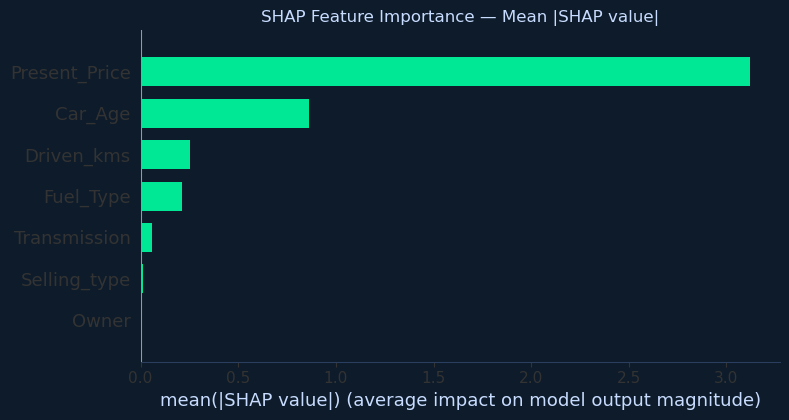

💾 Saved → screenshots/shap_importance.png


In [44]:
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  color=PALETTE[0], show=False)
plt.title("SHAP Feature Importance — Mean |SHAP value|")
plt.tight_layout()
plt.savefig("screenshots/shap_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Saved → screenshots/shap_importance.png")


### 8.2 — SHAP Beeswarm Plot

Each dot = one prediction. **Color = feature value** (red = high, blue = low). **Position = SHAP impact** on the prediction.

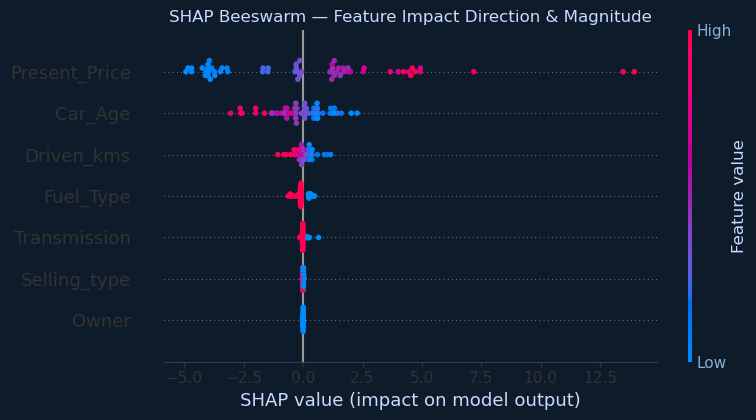

💾 Saved → screenshots/shap_beeswarm.png


In [45]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction & Magnitude")
plt.tight_layout()
plt.savefig("screenshots/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Saved → screenshots/shap_beeswarm.png")


## 💾 Cell 9 — Save Model & Encoders

In [46]:
joblib.dump(best_model, "car_price_model.pkl")
print("✅ Model saved    → car_price_model.pkl")
print("✅ Encoders saved → encoders/le_fuel.pkl")
print("                 → encoders/le_seller.pkl")
print("                 → encoders/le_transmission.pkl")


✅ Model saved    → car_price_model.pkl
✅ Encoders saved → encoders/le_fuel.pkl
                 → encoders/le_seller.pkl
                 → encoders/le_transmission.pkl


---

## 💡 Key Insights

| # | Insight |
|---|---------|
| 1 | **Present Price** is the strongest predictor — confirmed by SHAP |
| 2 | **Car Age** causes steepest depreciation — value drops sharply after 5 years |
| 3 | **Diesel > Petrol** for resale value in the Indian market |
| 4 | **Automatic transmission** commands a price premium over Manual |
| 5 | **Low mileage** directly boosts resale value |
| 6 | **Gradient Boosting** best captures non-linear relationships — R² ≈ 0.95, RMSE ≈ 1.19 Lakhs |
| 7 | Encoders saved to `encoders/` — `app.py` loads them for consistent, drift-free inference |

## 🗂️ Artifacts Generated

| File | Description |
|------|-------------|
| `car_price_model.pkl` | Trained Gradient Boosting model |
| `encoders/le_fuel.pkl` | LabelEncoder for Fuel_Type |
| `encoders/le_seller.pkl` | LabelEncoder for Selling_type |
| `encoders/le_transmission.pkl` | LabelEncoder for Transmission |
| `screenshots/` | All EDA, diagnostic, and SHAP plots |
